In [1]:
import sys

import torch

import pandas as pd

import pm4py
from pm4py.visualization.petri_net import visualizer as pn_vis

from config.feature_config import FeatureConfig
from config.ga_config import GAConfig

from utils.general_utils import set_stdout_to_file, set_seed
from utils.feature_utils import df_to_sequence_array

from model.preprocessor import PreprocessorArtifacts

from model.next_event_model import ProcessLSTM
from model.model_wrapper import ModelWrapper

from ga_search.search import CounterfactualGA

from process.engine import ProcessModelConstraintEngine
from process.experimenter import ExperimentHandler

### --- Load Dataset & Models ---

In [2]:
set_seed(seed=42)

In [3]:
df = pd.read_excel(
    "../../data/bpic20_Rfp.xlsx",
    engine="openpyxl",
    keep_default_na=False,
    dtype={
        "case:concept:name": "string",
        "concept:name": "string",
        "org:resource": "string",
        "org:role": "string",
        "case:Activity": "string",
        "case:OrganizationalEntity": "string",
        "case:RequestedAmount": "float32",
        "time_delta": "float32",
    }
)

df["time:timestamp"] = pd.to_datetime(df["time:timestamp"])

In [4]:
df.head(20)

,case:concept:name,time:timestamp,case:Activity,case:OrganizationalEntity,case:RequestedAmount,concept:name,org:resource,org:role,time_delta
0,request for payment 147529,2017-02-14 15:34:34,UNKNOWN,organizational unit 65458,137.526306,Request For Payment SUBMITTED by EMPLOYEE,STAFF MEMBER,EMPLOYEE,0.0
1,request for payment 147529,2017-02-14 15:34:43,UNKNOWN,organizational unit 65458,137.526306,Request For Payment FINAL_APPROVED by SUPERVISOR,STAFF MEMBER,SUPERVISOR,9.0
2,request for payment 147529,2017-02-15 14:48:02,UNKNOWN,organizational unit 65458,137.526306,Request Payment,SYSTEM,UNDEFINED,83599.0
3,request for payment 147529,2017-02-20 17:32:08,UNKNOWN,organizational unit 65458,137.526306,Payment Handled,SYSTEM,UNDEFINED,441846.0
4,request for payment 147534,2017-03-02 15:55:43,UNKNOWN,organizational unit 65463,59.567024,Request For Payment SUBMITTED by EMPLOYEE,STAFF MEMBER,EMPLOYEE,0.0
5,request for payment 147534,2017-03-02 15:58:27,UNKNOWN,organizational unit 65463,59.567024,Request For Payment APPROVED by PRE_APPROVER,STAFF MEMBER,PRE_APPROVER,164.0
6,request for payment 147534,2017-03-02 16:07:38,UNKNOWN,organizational unit 65463,59.567024,Request For Payment FINAL_APPROVED by SUPERVISOR,STAFF MEMBER,SUPERVISOR,551.0
7,request for payment 147534,2017-03-06 13:57:31,UNKNOWN,organizational unit 65463,59.567024,Request Payment,SYSTEM,UNDEFINED,337793.0
8,request for payment 147534,2017-03-13 17:31:05,UNKNOWN,organizational unit 65463,59.567024,Payment Handled,SYSTEM,UNDEFINED,617614.0
9,request for payment 147539,2017-03-06 14:40:07,UNKNOWN,organizational unit 65458,47.927757,Request For Payment SUBMITTED by EMPLOYEE,STAFF MEMBER,EMPLOYEE,0.0


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
feature_config = FeatureConfig.load()

In [7]:
feature_config.summary()

  activity_feature:    concept:name
  feature_order:       ['case:Activity', 'case:OrganizationalEntity', 'case:RequestedAmount', 'concept:name', 'org:resource', 'org:role', 'time_delta']
--------------------------------------------------------------------------------------------------------------------------------------
Feature                        Type           Level    Vary   Range/Categories                         MAD        Source              
--------------------------------------------------------------------------------------------------------------------------------------
time_delta                     continuous     event    yes    [3.00, 325445.40]                        57230.0000 quantile_derived    
case:RequestedAmount           continuous     case     yes    [10.54, 665.70]                          74.7009    quantile_derived    
org:resource                   categorical    event    yes    ['STAFF MEMBER', 'SYSTEM']               N/A        data_derived        
or

In [8]:
preprocessor_artifacts = PreprocessorArtifacts.load()

In [9]:
model = ProcessLSTM.load()

In [10]:
model_wrapper = ModelWrapper(
    model=model,
    preprocessor_artifacts=preprocessor_artifacts,
    device=device
)

### --- Process Constraints ---

In [11]:
net, initial_marking, final_marking = pm4py.discover_petri_net_inductive(
    df,
    noise_threshold=0.5,
    case_id_key='case:concept:name',  
    activity_key='concept:name',
    timestamp_key='time:timestamp'
)

engine = ProcessModelConstraintEngine(
    petri_net=net,
    initial_marking=initial_marking,
    final_marking=final_marking
)
engine.save()

In [12]:
# engine = ProcessModelConstraintEngine.load()

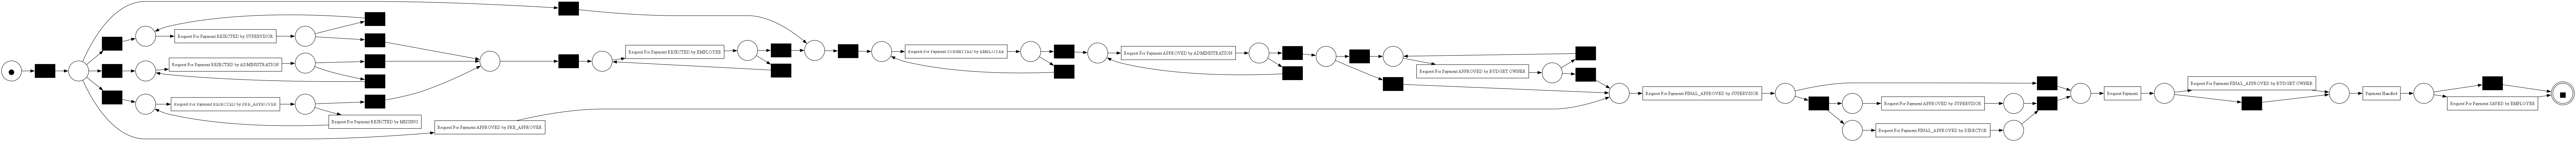

In [13]:
gviz = pn_vis.apply(
    net,
    initial_marking,
    final_marking,
)

pn_vis.view(gviz)

In [14]:
engine.parallel_sets

[{'Request For Payment APPROVED by SUPERVISOR',
  'Request For Payment FINAL_APPROVED by DIRECTOR'}]

In [15]:
engine.branching_sets

[{'Request For Payment APPROVED by ADMINISTRATION',
  'Request For Payment APPROVED by BUDGET OWNER',
  'Request For Payment APPROVED by PRE_APPROVER',
  'Request For Payment REJECTED by ADMINISTRATION',
  'Request For Payment REJECTED by EMPLOYEE',
  'Request For Payment REJECTED by MISSING',
  'Request For Payment REJECTED by PRE_APPROVER',
  'Request For Payment REJECTED by SUPERVISOR',
  'Request For Payment SUBMITTED by EMPLOYEE'},
 {'Request For Payment REJECTED by ADMINISTRATION',
  'Request For Payment REJECTED by EMPLOYEE',
  'Request For Payment REJECTED by MISSING',
  'Request For Payment REJECTED by PRE_APPROVER',
  'Request For Payment REJECTED by SUPERVISOR'},
 {'Request For Payment REJECTED by ADMINISTRATION',
  'Request For Payment REJECTED by MISSING',
  'Request For Payment REJECTED by PRE_APPROVER',
  'Request For Payment REJECTED by SUPERVISOR'},
 {'Request For Payment APPROVED by SUPERVISOR',
  'Request For Payment FINAL_APPROVED by DIRECTOR'}]

### --- Experiments Generation ---

In [16]:
log_file, original_stdout = set_stdout_to_file(filepath="logs/bpic20_Rfp-cf_generated_experiments_ga_output.txt", console=False)

In [17]:
generator = ExperimentHandler(
    constraint_engine=engine,
)

In [18]:
exp_df_sin = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_single_desired",
    min_desired=1,
    max_desired=1,
)

In [19]:
exp_df_mul = generator.generate_experiments_from_log(
    df=df,
    case_id_field="case:concept:name",
    activity_field="concept:name",
    sort_field="time:timestamp",
    save_path="experiments/cf_generated_experiments_multiple_desired",
    min_desired=2,
)

In [20]:
max(exp_df_sin['num_desired'])

1

In [21]:
len(exp_df_sin)

200

In [22]:
exp_df_sin.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,request for payment 176718,4,0,3,1,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{2: {'Request For Payment APPROVED by BUDGET O...,3013,1804,10,window_variant_mixed
1,0,request for payment 166711,5,0,3,1,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{2: {'Request For Payment APPROVED by BUDGET O...,3013,1804,10,window_variant_mixed
2,0,request for payment 184068,5,0,3,1,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{2: {'Request For Payment APPROVED by BUDGET O...,3013,1804,10,window_variant_mixed
3,0,request for payment 182365,5,0,3,1,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{2: {'Request For Payment APPROVED by BUDGET O...,3013,1804,10,window_variant_mixed
4,0,request for payment 168709,5,0,3,1,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{2: {'Request For Payment APPROVED by BUDGET O...,3013,1804,10,window_variant_mixed


In [23]:
min(exp_df_mul['num_desired'])

2

In [24]:
max(exp_df_mul['num_desired'])

9

In [25]:
len(exp_df_mul)

390

In [26]:
exp_df_mul.head()

,template_id,case:concept:name,trace_length,start_pos,length,num_desired,source_pattern,target_pattern,desired_positions,source_support,target_support,num_cases_for_template,experiment_type
0,0,request for payment 176718,4,0,3,2,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{1: {'Request For Payment REJECTED by ADMINIST...,3013,734,10,window_variant_mixed
1,0,request for payment 166711,5,0,3,2,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{1: {'Request For Payment REJECTED by ADMINIST...,3013,734,10,window_variant_mixed
2,0,request for payment 184068,5,0,3,2,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{1: {'Request For Payment REJECTED by ADMINIST...,3013,734,10,window_variant_mixed
3,0,request for payment 182365,5,0,3,2,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{1: {'Request For Payment REJECTED by ADMINIST...,3013,734,10,window_variant_mixed
4,0,request for payment 168709,5,0,3,2,"(Request For Payment SUBMITTED by EMPLOYEE, Re...","(Request For Payment SUBMITTED by EMPLOYEE, Re...",{1: {'Request For Payment REJECTED by ADMINIST...,3013,734,10,window_variant_mixed


In [27]:
# exp_df_sin, metadata_sin = ExperimentHandler.load("experiments/cf_generated_experiments_single_desired")
# print("Mined using parameters:", metadata_sin["parameters"])

# exp_df_mul, metadata_mul = ExperimentHandler.load("experiments/cf_generated_experiments_multiple_desired")
# print("Mined using parameters:", metadata_mul["parameters"])

### --- Counterfactuals ---

In [28]:
ga_config = GAConfig(
    w_distance=1.0,
    w_sparsity=1.0,
    w_margin=1.0,
    w_process_violation=1.0,
)
ga_config.validate()

cf_GA = CounterfactualGA(
    ga_config=ga_config,
    feature_config=feature_config,
    model_wrapper=model_wrapper
)

In [29]:
results_sin = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_single_desired",
    exp_df=exp_df_sin,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/200 [00:00<?, ?case/s]

In [30]:
results_sin

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,request for payment 176718,4,1,0,0.390180,0.305359,0.475000,0.566667,0.181818,...,0.599534,0.181818,0.084382,0.166667,0.002098,0.333333,0.0,0.000000,0.0,0.000000
1,0,request for payment 166711,5,1,0,0.402074,0.337480,0.466667,0.466667,0.292308,...,0.307692,0.307692,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
2,0,request for payment 184068,5,1,0,0.351086,0.268839,0.433333,0.450000,0.307692,...,0.502137,0.307692,0.083333,0.166667,0.000000,0.111111,0.0,0.000000,0.0,0.000000
3,0,request for payment 182365,5,1,0,0.400158,0.375316,0.425000,0.477778,0.261538,...,0.307692,0.307692,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.000000
4,0,request for payment 168709,5,1,0,0.373462,0.288591,0.458333,0.505556,0.307692,...,0.620752,0.307692,0.090837,0.166667,0.015008,0.222222,0.0,0.000000,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130,16,request for payment 178121,9,1,0,0.476322,0.449072,0.503571,0.623810,0.285714,...,0.764872,0.285714,0.145824,0.142857,0.148791,0.333333,0.0,0.895667,0.0,1.000000
131,16,request for payment 170670,9,1,0,0.451604,0.381779,0.521429,0.588095,0.285714,...,0.723402,0.285714,0.151974,0.214286,0.089662,0.285714,0.0,0.845873,0.0,1.000000
132,16,request for payment 171283,9,1,0,0.444541,0.374797,0.514286,0.571429,0.285714,...,0.694580,0.285714,0.170770,0.142857,0.198684,0.238095,0.0,0.764620,0.0,0.999999
133,16,request for payment 171342,9,1,0,0.393197,0.293537,0.492857,0.561905,0.285714,...,0.610781,0.285714,0.086972,0.142857,0.031086,0.238095,0.0,0.849644,0.0,1.000000


In [31]:
results_mul = generator.run_experiment_df(
    cf_method=cf_GA,
    technique="GA_multiple_desired",
    exp_df=exp_df_mul,
    df=df,
    feature_config=feature_config,
    case_id_field="case:concept:name",
    sort_field="time:timestamp",
)

Experiments:   0%|          | 0/390 [00:00<?, ?case/s]

In [32]:
results_mul

,template_id,case:concept:name,trace_length,num_desired,num_flexible,DISTANCE,CONT_DISTANCE,CAT_DISTANCE,SPARSITY,PROCESS_VIOLATION,...,best_cf_fitness,best_cf_process_violation,best_cf_distance,best_cf_cat_distance,best_cf_cont_distance,best_cf_sparsity,best_cf_margin_loss,best_cf_margin_loss_na,best_cf_margin_loss_flipped,best_cf_margin_loss_na_flipped
0,0,request for payment 176718,4,2,0,0.379506,0.309013,0.4500,0.475000,0.285714,...,0.832460,0.142857,0.250,0.50,0.0,0.333333,0.106269,0.586707,0.000000,0.500000
1,0,request for payment 166711,5,2,0,0.538113,0.401225,0.6750,0.675000,0.312500,...,0.541667,0.250000,0.125,0.25,0.0,0.166667,0.000000,0.473461,0.000000,0.500000
2,0,request for payment 184068,5,2,0,0.519590,0.401681,0.6375,0.625000,0.300000,...,0.833333,0.250000,0.250,0.50,0.0,0.333333,0.000000,0.472643,0.000000,0.500000
3,0,request for payment 182365,5,2,0,0.433518,0.292036,0.5750,0.566667,0.275000,...,0.760639,0.250000,0.125,0.25,0.0,0.166667,0.218972,0.692573,0.000000,0.500000
4,0,request for payment 168709,5,2,0,0.545281,0.540561,0.5500,0.625000,0.256250,...,0.697682,0.250000,0.250,0.00,0.5,0.166667,0.031015,0.509098,0.000000,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241,38,request for payment 166918,10,9,0,0.532612,0.515224,0.5500,0.583333,0.364894,...,1.339030,0.000000,0.625,0.75,0.5,0.666667,0.047363,0.850766,0.000000,0.888889
242,38,request for payment 170921,10,9,0,0.427171,0.479341,0.3750,0.458333,0.668085,...,1.337842,0.531915,0.125,0.25,0.0,0.166667,0.514260,0.851383,0.555555,0.888889
243,38,request for payment 176296,10,9,0,0.545842,0.529185,0.5625,0.641667,0.554255,...,1.047363,0.000000,0.500,0.50,0.5,0.500000,0.047363,0.843039,0.000000,0.888889
244,38,request for payment 160855,10,9,0,0.466460,0.432920,0.5000,0.508333,0.711702,...,1.338914,0.531915,0.125,0.25,0.0,0.166667,0.515333,0.849444,0.555555,0.888889


### --- Cleanup ---

In [33]:
sys.stdout = original_stdout
log_file.close()